# HealthConnect Experience Lab - Machine Learning Problem Definition
### Week 4: AnalystLab Africa - Data Science Track
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI
**Central Project Question:** How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?
**Track objective this week:** define the machine learning problem and assess whether the available data can support a no-show prediction solution. This is a planning and assessment notebook , no model is trained this week.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 1. Problem Definition

**Business problem:** HealthConnect Clinic loses appointment capacity and administrative efficiency when patients fail to attend scheduled appointments without cancelling in advance. Missed appointments waste clinical time, delay care for other patients, and complicate scheduling.

**Machine learning framing:** this is a **binary classification problem**. Given information known *at or before the time of booking / reminder* (patient history, appointment characteristics, reminder behaviour), predict whether a given upcoming appointment is likely to result in a **no-show**.

**Why this is a reasonable ML problem:**
- The outcome (`appointment_outcome`) is recorded per appointment, giving a clear label to learn from.
- Several candidate predictors are available before the appointment occurs (booking lead time, patient's prior no-show history, reminder channel, distance to clinic), meaning a model's prediction would arrive early enough to be actionable (e.g. clinic staff could follow up with an extra reminder or phone call for high-risk patients).
- With 5,000 historical appointments, there is a reasonable though not large amount of data to begin assessing feasibility.

**Intended use of the model:** *not* to deny or penalise patients, but to help clinic staff proactively identify appointments at elevated no-show risk so they can intervene (extra reminder, phone call, or overbooking that slot appropriately) a decision-support tool, consistent with the Knowledge Base's emphasis on supporting, not replacing, clinic staff decisions.

## 2. Initial Data Assessment

In [2]:
print(f"Shape: {df.shape[0]} rows (appointments), {df.shape[1]} columns")
print(f"Unique patients: {df['patient_id'].nunique()} (appointments per patient can repeat)")
print(f"Date range - booking: {df['booking_date'].min().date()} to {df['booking_date'].max().date()}")
print(f"Date range - appointment: {df['appointment_date'].min().date()} to {df['appointment_date'].max().date()}")

Shape: 5000 rows (appointments), 18 columns
Unique patients: 1696 (appointments per patient can repeat)
Date range - booking: 2024-11-07 to 2026-06-27
Date range - appointment: 2025-01-01 to 2026-06-30


In [3]:
df.dtypes

appointment_id                   object
patient_id                       object
gender                           object
age                               int64
age_group                        object
appointment_type                 object
booking_date             datetime64[ns]
appointment_date         datetime64[ns]
appointment_day                  object
appointment_time                 object
booking_lead_days                 int64
previous_appointments             int64
previous_no_shows                 int64
reminder_sent                    object
reminder_channel                 object
distance_to_clinic_km           float64
waiting_time_minutes            float64
appointment_outcome              object
dtype: object

In [4]:
missing = df.isnull().sum()
missing[missing > 0]

reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64

**Missing values identified:**
- `reminder_channel`: 1,366 missing expected and explainable, since the data dictionary notes this is blank whenever `reminder_sent = No` (confirmed below). Not a data quality defect.
- `distance_to_clinic_km`: 90 missing (1.8%) and `waiting_time_minutes`: 60 missing (1.2%), the data dictionary flags both as containing "limited missing values"; low enough to handle with standard imputation (e.g. median) without materially affecting the dataset.

In [5]:
# Confirm reminder_channel is missing exactly when no reminder was sent
pd.crosstab(df['reminder_sent'], df['reminder_channel'].isnull())

reminder_channel,False,True
reminder_sent,,
No,0,1366
Yes,3634,0


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())
print("previous_no_shows > previous_appointments (logical error check):", (df['previous_no_shows'] > df['previous_appointments']).sum())
print("Negative booking_lead_days:", (df['booking_lead_days'] < 0).sum())

Duplicate rows: 0
Duplicate appointment_id: 0
previous_no_shows > previous_appointments (logical error check): 0
Negative booking_lead_days: 0


**Consistency checks:** no duplicate rows or appointment IDs, no logically invalid records (no patient has more previous no-shows than previous appointments), and no negative booking lead times. This synthetic dataset appears to have been generated cleanly the main preprocessing need is straightforward missing-value handling, not error correction.

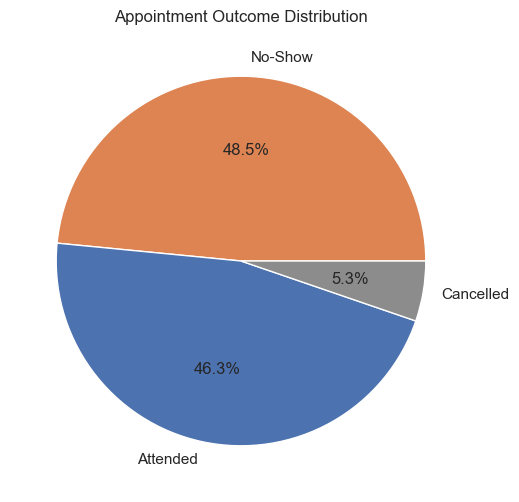

In [7]:
plt.figure(figsize=(6,6))
df['appointment_outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['#DD8452', '#4C72B0', '#8C8C8C'])
plt.title('Appointment Outcome Distribution')
plt.ylabel('')
plt.show()

### Handling of appointment outcomes (including cancellations)
`appointment_outcome` has **three** categories: Attended (46.3%), No-Show (48.5%), and Cancelled (5.3%). These are not equivalent behaviours:
- A **No-Show** is a patient who took no action and simply did not attend this is the behaviour the clinic most wants to predict and reduce, since it wastes a slot with no advance warning.
- A **Cancelled** appointment is a patient proactively freeing up their slot in advance operationally very different, and arguably a *desired* behaviour compared to a silent no-show, since it gives the clinic a chance to fill the slot.

**Decision:** the primary target variable will be built from **Attended vs No-Show only**. Cancelled appointments (263 records, 5.3%) will be **excluded from initial model training**, since including them as either class would blur two operationally distinct behaviours and could mislead the model and the clinic's response strategy. This decision is documented here rather than made silently in code, per the Week 4 task requirements. A future iteration could explore cancellations as a separate secondary model (e.g. predicting *any* non-attendance, or predicting cancellations specifically to understand rebooking patterns) noted as a possible Week 5+ extension, not required now.

In [8]:
df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)
print(f"Records available for modelling (Attended + No-Show): {len(df_model)}")
print(df_model['no_show'].value_counts(normalize=True).round(3) * 100)

Records available for modelling (Attended + No-Show): 4737
no_show
1    51.2
0    48.8
Name: proportion, dtype: float64


**Class balance:** after excluding cancellations, the target is close to balanced (51.2% No-Show / 48.8% Attended), which is favourable no severe class-imbalance handling (e.g. SMOTE) is anticipated to be necessary, though this should be re-confirmed once the final modelling dataset is fixed.

## 3. Proposed Target Variable

**Target:** `no_show` a binary variable derived from `appointment_outcome`, equal to 1 if the outcome is `No-Show` and 0 if `Attended`. Cancelled appointments are excluded from the modelling dataset (see Section 2).

This framing directly answers the clinic's central question ("reduce missed appointments") with a target that is well-defined, unambiguous, and available for every appointment in the historical data.

## 4. Potential Input Features
Candidate features are grouped by type, with an initial (exploratory, non-final) look at their relationship to the target to inform not conclude their eventual inclusion.

In [9]:
candidate_numeric = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                      'distance_to_clinic_km', 'waiting_time_minutes']
corr_with_target = df_model[candidate_numeric + ['no_show']].corr()['no_show'].drop('no_show')
corr_with_target.sort_values(key=abs, ascending=False)

booking_lead_days        0.287255
previous_no_shows        0.122892
distance_to_clinic_km    0.065213
previous_appointments    0.042421
age                     -0.028446
waiting_time_minutes    -0.004062
Name: no_show, dtype: float64

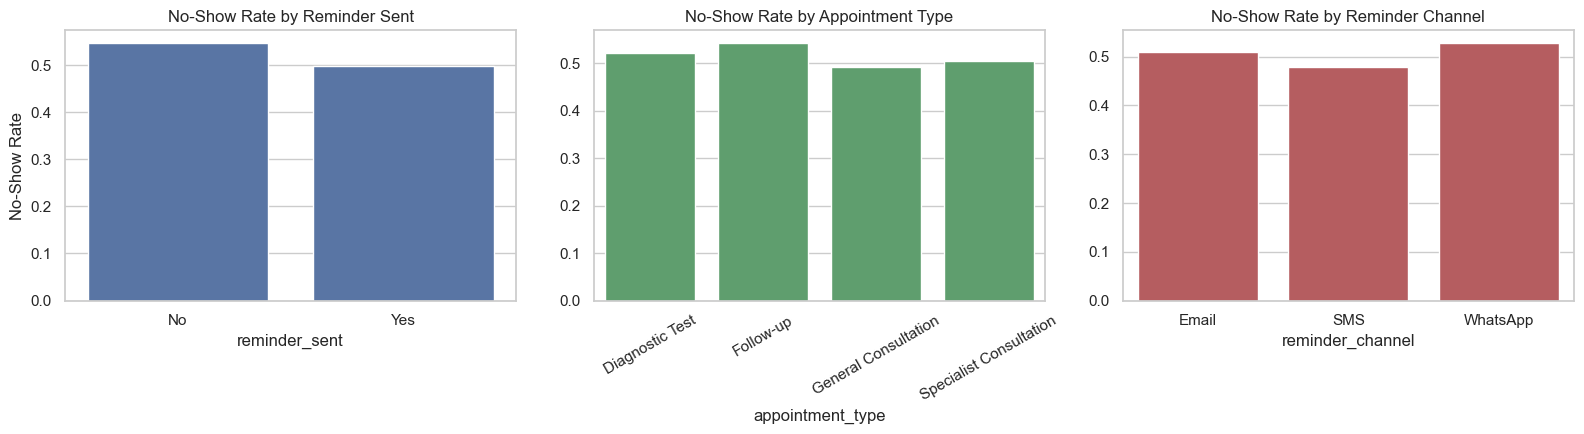

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(x=df_model.groupby('reminder_sent')['no_show'].mean().index,
            y=df_model.groupby('reminder_sent')['no_show'].mean().values, ax=axes[0], color='#4C72B0')
axes[0].set_title('No-Show Rate by Reminder Sent')
axes[0].set_ylabel('No-Show Rate')

sns.barplot(x=df_model.groupby('appointment_type')['no_show'].mean().index,
            y=df_model.groupby('appointment_type')['no_show'].mean().values, ax=axes[1], color='#55A868')
axes[1].set_title('No-Show Rate by Appointment Type')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(x=df_model.groupby('reminder_channel')['no_show'].mean().index,
            y=df_model.groupby('reminder_channel')['no_show'].mean().values, ax=axes[2], color='#C44E52')
axes[2].set_title('No-Show Rate by Reminder Channel')
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

**Initial observations (exploratory only, not confirmatory):**
- `booking_lead_days` shows the strongest correlation with no-show (r ≈ 0.29) appointments booked further in advance appear more likely to be missed, plausibly because plans change over a longer window.
- `previous_no_shows` shows a modest positive correlation (r ≈ 0.12) a patient's own history is informative, as expected.
- `distance_to_clinic_km`, `waiting_time_minutes`, and `age` show weak correlation individually they may still add value in combination with other features, or may prove to have limited value once modelling begins.
- No-show rates appear broadly similar across reminder channels and appointment types in this dataset, though this should be assessed more formally (e.g. with a Chi-Square test) before drawing conclusions that level of statistical validation is intentionally out of scope for this Week 4 planning document.

**Proposed candidate features for the initial model:**
| Feature | Type | Rationale |

|---|---|---|

| `booking_lead_days` | Numeric | Strongest observed individual relationship with the target |

| `previous_no_shows` | Numeric | Direct behavioural history signal |

| `previous_appointments` | Numeric | Provides context/denominator for previous_no_shows |

| `age` | Numeric | Demographic factor, weak alone but may interact with others |

| `distance_to_clinic_km` | Numeric | Practical attendance barrier |

| `waiting_time_minutes` | Numeric | Possible proxy for past experience at the clinic |

| `reminder_sent` | Binary categorical | Directly actionable - the clinic controls this |

| `reminder_channel` | Categorical | Also actionable; may matter which channel patients respond to |

| `appointment_type` | Categorical | Different appointment types may carry different urgency/attendance patterns |

| `appointment_day` / `appointment_time` | Categorical | Scheduling factors that may correlate with attendance |

| `gender`, `age_group` | Categorical | Demographic context |

**Explicitly excluded from modelling:** `appointment_id` and `patient_id` (identifiers, not predictive features though `patient_id` could later support a patient-level historical aggregate feature, distinct from using the ID itself), and `appointment_outcome` / `appointment_date` / `booking_date` as raw fields (the outcome is the target itself; the raw dates are better represented through the derived `booking_lead_days`, `appointment_day`, and `appointment_time` fields already provided, to avoid the model simply memorising specific calendar dates that will not recur in future data).

## 5. Initial Modelling Approach

**Planned approach (for Week 5 onward, not this week):**
1. **Data preparation:** impute the limited missing values in `distance_to_clinic_km` and `waiting_time_minutes` (median imputation is a reasonable starting point given the low missingness rate); encode categorical variables (binary Label Encoding for `reminder_sent`/`gender`, One-Hot Encoding for nominal categories like `appointment_type`/`reminder_channel`/`appointment_day`/`appointment_time`).
2. **Train/test split:** given the data spans booking dates from November 2024 to June 2026, a **time-based split** (train on earlier appointments, test on later ones) is likely more realistic than a random split, since it better simulates how the model would actually be used predicting future appointments from past patterns. This should be confirmed once the final modelling dataset is prepared.
3. **Baseline model:** start with an interpretable baseline (e.g. Logistic Regression) to establish a reference performance level and to understand which features drive predictions in an explainable way important for a healthcare-adjacent, decision-support use case where staff will want to trust and understand the model's reasoning.
4. **Candidate models to compare:** Logistic Regression (baseline/interpretability), Random Forest and/or Gradient Boosting (to capture potential non-linear relationships and feature interactions).
5. **Evaluation metrics:** given the roughly balanced classes, accuracy is a reasonable headline metric, but precision, recall, F1-score, and ROC-AUC should also be tracked recall on the No-Show class is likely to matter most operationally (missing a true no-show has a real cost in wasted clinic time), so this will be a key metric to prioritise once modelling begins.

**Key modelling considerations / risks:**
- The correlations observed in Section 4 are modest in magnitude this is a synthetic dataset and it is not yet clear how predictive a model built on these features will actually be. Week 5 should include an early "sanity check" baseline model specifically to assess feasibility before investing further effort.
- `previous_no_shows` and `previous_appointments` are only meaningful for returning patients first-time patients (if any exist with zero prior appointments) will have limited history-based signal, which may need a specific handling strategy (e.g. a "new patient" flag).
- Because `patient_id` can repeat across appointments (1,696 unique patients across 5,000 appointments), a random row-level train/test split could leak information about a patient's outcome from the training set into the test set. A patient-aware or time-based split should be used instead to produce a realistic performance estimate.
- Any deployed model should be paired with a clear, non-punitive intervention plan (e.g. an extra reminder), consistent with the project's framing of supporting, not penalising, patients.

## Summary

This notebook defines a binary classification problem predicting patient no-shows from appointment and history data as HealthConnect Clinic's Data Science contribution to the shared HealthConnect Experience Lab project. The dataset (5,000 appointments) is clean and well-structured, requires only minor missing-value handling, and shows early (exploratory, not yet confirmed) signal in booking lead time and prior no-show history. Cancellations are explicitly excluded from the primary target definition, with a documented rationale. Week 5 will begin with data preparation and a baseline model to test the feasibility established here.